In [ ]:
from google.colab import drive
import zipfile
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
zip_path = '/content/drive/MyDrive/Plant_Disease_Classification_224.zip'

In [ ]:
extract_path = '/content/Plant_Disease_Classification_224'

In [ ]:
import os
os.makedirs(extract_path, exist_ok=True)

In [ ]:
import zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset unzipped successfully!")
print("Files are available at:", extract_path)

Dataset unzipped successfully!
Files are available at: /content/Plant_Disease_Classification_224


In [ ]:
os.listdir(extract_path)

['train',
 'valid',
 'test.csv',
 'valid.csv',
 'test',
 'label.num_disease.json',
 'train.csv']

In [ ]:
import os
import json
import pandas as pd

In [ ]:
DATASET_PATH = "/content/Plant_Disease_Classification_224"

In [ ]:
train_dir = os.path.join(DATASET_PATH, "train")
valid_dir = os.path.join(DATASET_PATH, "valid")
test_dir  = os.path.join(DATASET_PATH, "test")

In [ ]:
train_csv_path = os.path.join(DATASET_PATH, "train.csv")
valid_csv_path = os.path.join(DATASET_PATH, "valid.csv")
test_csv_path  = os.path.join(DATASET_PATH, "test.csv")

In [ ]:
label_json_path = os.path.join(DATASET_PATH, "label_num_disease.json")

In [ ]:
train_df = pd.read_csv(train_csv_path)
valid_df = pd.read_csv(valid_csv_path)
test_df = pd.read_csv(test_csv_path)

In [ ]:
label_json_path = os.path.join(DATASET_PATH, "label.num_disease.json")

with open(label_json_path, "r") as f:
    label_map = json.load(f)

print("Dataset loaded successfully!")
print("Train images folder:", train_dir)
print("Valid images folder:", valid_dir)
print("Test images folder:", test_dir)

print("\nTrain CSV shape:", train_df.shape)
print("Valid CSV shape:", valid_df.shape)
print("Test CSV shape:", test_df.shape)

print("\nTrain CSV columns:")
print(train_df.columns)

print("\nLabel mapping:")
print(label_map)

Dataset loaded successfully!
Train images folder: /content/Plant_Disease_Classification_224/train
Valid images folder: /content/Plant_Disease_Classification_224/valid
Test images folder: /content/Plant_Disease_Classification_224/test

Train CSV shape: (5000, 3)
Valid CSV shape: (1448, 3)
Test CSV shape: (1930, 3)

Train CSV columns:
Index(['image_path', 'label', 'disease_name'], dtype='object')

Label mapping:
{'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


In [ ]:
train_df.head()

,image_path,label,disease_name
0,train/Cassava___bacterial_blight/2932123995_jp...,0,Cassava___bacterial_blight
1,train/Cassava___bacterial_blight/1410898675_jp...,0,Cassava___bacterial_blight
2,train/Cassava___bacterial_blight/416062259_jpg...,0,Cassava___bacterial_blight
3,train/Cassava___bacterial_blight/2998282647_jp...,0,Cassava___bacterial_blight
4,train/Cassava___bacterial_blight/3504991692_jp...,0,Cassava___bacterial_blight


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

valid_test_datagen = ImageDataGenerator()

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

valid_generator = valid_test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = valid_test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 5000 images belonging to 5 classes.
Found 1448 images belonging to 5 classes.
Found 1930 images belonging to 5 classes.


In [ ]:
print("Number of classes:", train_generator.num_classes)
print("Class names:", train_generator.class_indices)

Number of classes: 5
Class names: {'Cassava___bacterial_blight': 0, 'Cassava___brown_streak_disease': 1, 'Cassava___green_mottle': 2, 'Cassava___healthy': 3, 'Cassava___mosaic_disease': 4}


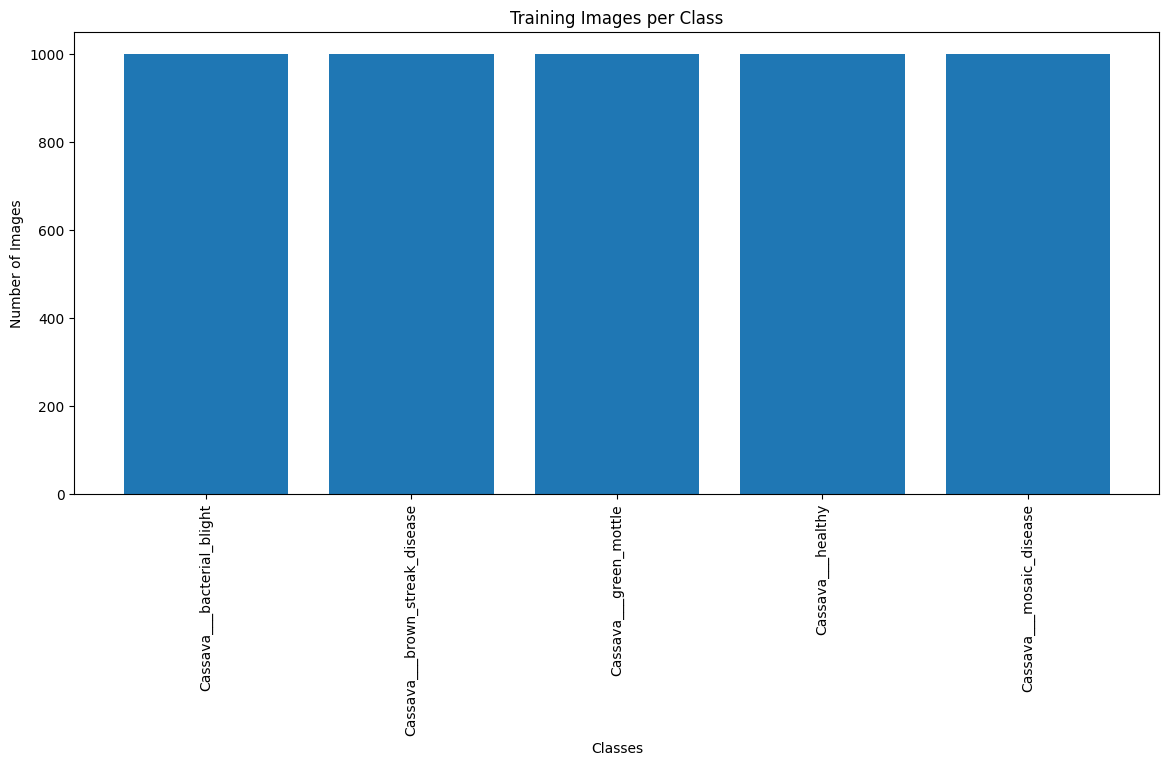

In [ ]:
import matplotlib.pyplot as plt
import os

class_names = list(train_generator.class_indices.keys())
class_counts = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    count = len(os.listdir(class_path))
    class_counts.append(count)

plt.figure(figsize=(14, 6))
plt.bar(class_names, class_counts)
plt.xticks(rotation=90)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Training Images per Class")
plt.show()

In [ ]:
for name, count in zip(class_names, class_counts):
    print(name, ":", count)

Cassava___bacterial_blight : 1000
Cassava___brown_streak_disease : 1000
Cassava___green_mottle : 1000
Cassava___healthy : 1000
Cassava___mosaic_disease : 1000


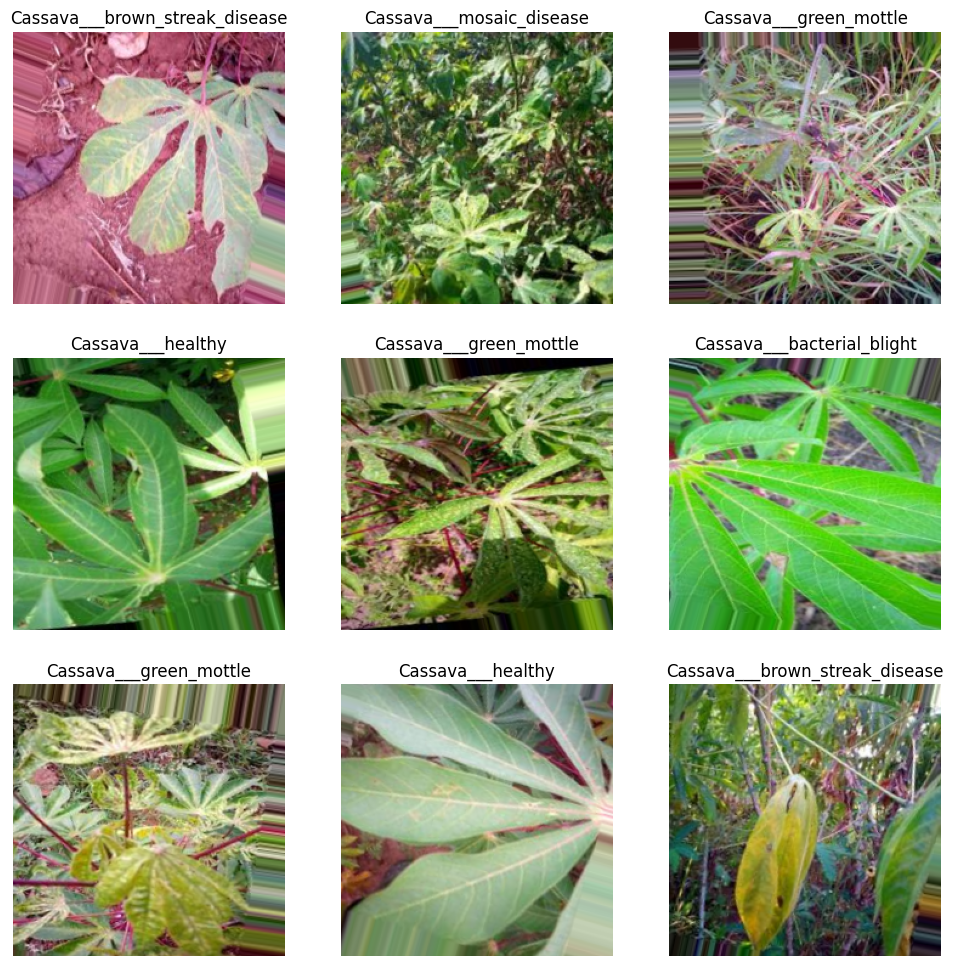

In [ ]:
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(12, 12))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    # Normalize the image data to the [0, 1] range for proper display
    plt.imshow(images[i] / 255.0)

    class_index = np.argmax(labels[i])
    class_name = class_names[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model

NUM_CLASSES = train_generator.num_classes

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(128, activation="relu")(x)
x = Dropout(0.2)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,411,048 (16.83 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

callbacks = [
    ModelCheckpoint(
        "best_efficientnetb0_stage1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history1 = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 525ms/step - accuracy: 0.2855 - loss: 1.5547
Epoch 1: val_accuracy improved from None to 0.45166, saving model to best_efficientnetb0_stage1.keras

Epoch 1: finished saving model to best_efficientnetb0_stage1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 132s 632ms/step - accuracy: 0.3368 - loss: 1.4923 - val_accuracy: 0.4517 - val_loss: 1.3609 - learning_rate: 1.0000e-04
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.4332 - loss: 1.3472
Epoch 2: val_accuracy improved from 0.45166 to 0.52486, saving model to best_efficientnetb0_stage1.keras

Epoch 2: finished saving model to best_efficientnetb0_stage1.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 67s 424ms/step - accuracy: 0.4432 - loss: 1.3276 - val_accuracy: 0.5249 - val_loss: 1.2383 - learning_rate: 1.0000e-04
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.5026 - loss: 1.2443
Epoch 3: val_accuracy improved from 0.52486 to 0.53591, saving model to best_efficientnetb0_stag

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

for layer in base_model.layers[-40:]:
    layer.trainable = True

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
fine_callbacks = [
    ModelCheckpoint(
        "best_efficientnetb0_finetuned.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4,
        min_lr=1e-6,
        verbose=1
    )
]

In [ ]:
history_fine = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=fine_callbacks
)

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 508ms/step - accuracy: 0.4758 - loss: 1.2694
Epoch 1: val_accuracy improved from None to 0.49517, saving model to best_efficientnetb0_finetuned.keras

Epoch 1: finished saving model to best_efficientnetb0_finetuned.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 129s 607ms/step - accuracy: 0.4896 - loss: 1.2435 - val_accuracy: 0.4952 - val_loss: 1.2194 - learning_rate: 1.0000e-05
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.5277 - loss: 1.1669
Epoch 2: val_accuracy improved from 0.49517 to 0.50898, saving model to best_efficientnetb0_finetuned.keras

Epoch 2: finished saving model to best_efficientnetb0_finetuned.keras
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 431ms/step - accuracy: 0.5340 - loss: 1.1561 - val_accuracy: 0.5090 - val_loss: 1.1931 - learning_rate: 1.0000e-05
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.5477 - loss: 1.1296
Epoch 3: val_accuracy improved from 0.50898 to 0.53315, saving model to best_efficie

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("best_efficientnetb0_finetuned.keras")

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("best_efficientnetb0_finetuned.keras")

test_loss, test_accuracy = best_model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 134ms/step - accuracy: 0.6358 - loss: 0.9662
Test Loss: 0.9662090539932251
Test Accuracy: 0.6357513070106506


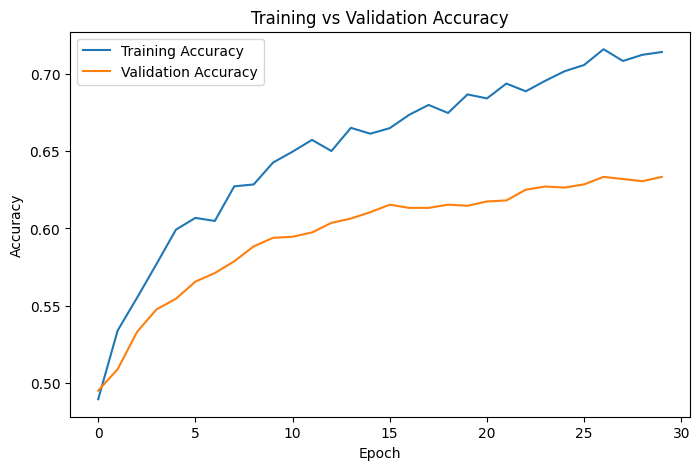

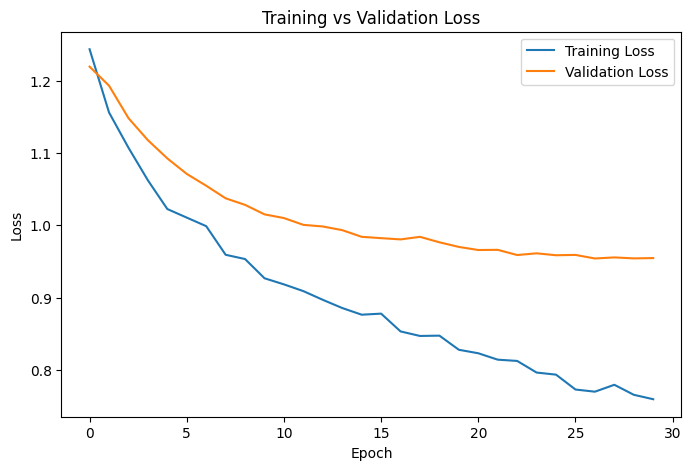

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_fine.history["accuracy"], label="Training Accuracy")
plt.plot(history_fine.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_fine.history["loss"], label="Training Loss")
plt.plot(history_fine.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()